In [1]:
import torch
import transformers
import sys
import os
import matplotlib.pyplot as plt
import json
import seaborn as sns
import collections
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("../")
from utils import experiment_logger
from secalign_refactored import secalign, config
# 模型路径
model_rel_path = "/home/dataset/2024_zox_llm/code/better_opts_attacks/secalign_refactored/secalign_models/mistralai/Mistral-7B-v0.1_SpclSpclSpcl_None_2025-03-12-01-02-08"

load_model = True
load_tokenizer = True
max_memory = {0: "10GiB", 1: "10GiB",2: "10GiB",  3: "10GiB", "cpu": "16GiB"}#2: "10GiB",
if load_model and load_tokenizer:
    model, tokenizer, frontend_delimiters, _ = secalign.load_lora_model(model_rel_path, load_model=load_model, device_map="auto",max_memory=max_memory)

    inst_delm = config.DELIMITERS[frontend_delimiters][0]
    data_delm = config.DELIMITERS[frontend_delimiters][1]
    resp_delm = config.DELIMITERS[frontend_delimiters][2]

    prompt_template = config.PROMPT_FORMAT[frontend_delimiters]
    model = model.eval()
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.temperature = 0.0
    model.generation_config.do_sample=False
elif load_tokenizer and not load_model:
    model = None
    configs = model_rel_path.split('/')[-1].split('_') + ['Frontend-Delimiter-Placeholder', 'None']
    for alignment in ['dpo', 'kto', 'orpo']:
        base_model_index = model_rel_path.find(alignment) - 1
        if base_model_index > 0: break
        else: base_model_index = False

    base_model_path = model_rel_path[:base_model_index] if base_model_index else model_rel_path
    frontend_delimiters = configs[1] if configs[1] in config.DELIMITERS else base_model_path.split('/')[-1]
    training_attacks = configs[2]

    tokenizer = transformers.AutoTokenizer.from_pretrained(base_model_path)

    prompt_template = config.PROMPT_FORMAT[frontend_delimiters]["prompt_input"]

else:
    model, tokenizer, frontend_delimiters, _ = None, None, None, None


模型地址为 /home/dataset/2024_zox_llm/code/better_opts_attacks/secalign_refactored/secalign_models/mistralai/Mistral-7B-v0.1_SpclSpclSpcl_None_2025-03-12-01-02-08


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


缺少默认的 chat 模板


normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


In [2]:
# # 日志路径
# def plot_training_logs(logger, num_rounds, points_per_round, gap=5):

#     token_prefix_suffix_sequences  = next(logger.query({"variable_name": "astra_tokens_sequences_list"}))
#     round_loss_matrix = list(logger.query({"variable_name": "current_best_true_loss_chunk"}))
#     attn_prefix_suffix_matrix  = list(logger.query({"variable_name": "prefix_suffix_attention_list"}))
#     attn_payload_matrix  = list(logger.query({"variable_name": "payload_attention_list"}))
#     attn_background_matrix  = list(logger.query({"variable_name": "other_attention_list"}))
#     round_asr_matrix = next(logger.query({"variable_name": "astra_logprobs_lists_list"}))

#     loss_matrix = next(logger.query({"variable_name": "current_best_true_loss_chunk"}))
#     loss_list = [float(x) for x in loss_matrix]
#     loss_2d = [
#         loss_list[i * points_per_round : (i + 1) * points_per_round]
#         for i in range(num_rounds)
#     ]
#     print(loss_2d)


#     # print(len(round_loss_matrix))
#     # print(len(attn_prefix_suffix_matrix))
#     print(attn_payload_matrix)
#     # print(len(attn_background_matrix))
#     # print(len(round_asr_matrix))

#     attn_prefix_suffix_scaled = []
#     attn_payload_scaled = []
#     attn_background_scaled = []

#     for i in range(num_rounds):
#         # 转tensor到CPU
#         prefix = torch.tensor(attn_prefix_suffix_matrix[i].cpu() if hasattr(attn_prefix_suffix_matrix[i], "cpu") else attn_prefix_suffix_matrix[i])
#         payload = torch.tensor(attn_payload_matrix[i].cpu() if hasattr(attn_payload_matrix[i], "cpu") else attn_payload_matrix[i])
#         background = torch.tensor(attn_background_matrix[i].cpu() if hasattr(attn_background_matrix[i], "cpu") else attn_background_matrix[i])

        

#         total = prefix + payload + background
#         # 避免除0
#         total[total == 0] = 1e-8
#         scale = 100.0 / total

#         attn_prefix_suffix_scaled.append(prefix * scale)
#         attn_payload_scaled.append(payload * scale)
#         attn_background_scaled.append(background * scale)


#     metric_dict = {
#         # "True Loss": round_loss_matrix,
#         "Prefix-Suffix Attention": attn_prefix_suffix_scaled,
#         "Payload Attention": attn_payload_scaled,
#         "Background Attention": attn_background_scaled,
#         "ASR": round_asr_matrix,
#         # "loss":loss_2d
#     }


#     colors = ["C0", "C1", "C2", "C3", "C4"]

#     plt.figure(figsize=(14, 8))

#     for idx, (metric_name, metric_data) in enumerate(metric_dict.items()):
#         color = colors[idx % len(colors)]


#         if isinstance(metric_data, list):
#             tensor_list = []
#             for x in metric_data:
#                 t = x
#                 if hasattr(x, "cpu"):
#                     t = x.cpu()
#                 tensor_list.append(torch.tensor(t))
#             metric_tensor = torch.stack(tensor_list)  # shape: [num_rounds, points_per_round]
#         elif hasattr(metric_data, "cpu"):
#             metric_tensor = metric_data.cpu()
#         else:
#             metric_tensor = torch.tensor(metric_data)


#         for round_idx in range(1):#num_rounds
#             x_round = [i + round_idx*(points_per_round + gap) for i in range(points_per_round)]
#             y_round = metric_tensor[round_idx].flatten().cpu().numpy()
#             plt.plot(x_round, y_round, color=color)


#     plt.title("Metrics Across Rounds (Attention scaled to 100 per round)")
#     plt.xlabel("Steps (round-separated)")
#     plt.ylabel("Metric Value")
#     plt.grid(True, linestyle="--", alpha=0.5)


#     from matplotlib.lines import Line2D
#     custom_lines = [Line2D([0], [0], color=colors[i % len(colors)], lw=2) for i in range(len(metric_dict))]
#     plt.legend(custom_lines, metric_dict.keys())

#     plt.tight_layout()
#     plt.show()
    

# # logger_sst_2_10_15 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_10-15/")
# # plot_training_logs(logger_sst_2_10_15,5,50)

# # logger_sst_2_15_10 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_15-10/")
# # plot_training_logs(logger_sst_2_15_10,5,100)

# logger_sst_2_0_25 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25/")
# plot_training_logs(logger_sst_2_0_25,1,50)






In [3]:
# # 日志路径
# def plot_training_logs(logger, num_rounds, points_per_round, gap=5):

#     token_prefix_suffix_sequences  = next(logger.query({"variable_name": "astra_tokens_sequences_list"}))
#     attn_prefix_suffix_matrix  = list(logger.query({"variable_name": "prefix_suffix_attention_list"}))
#     attn_payload_matrix  = list(logger.query({"variable_name": "payload_attention_list"}))
#     attn_background_matrix  = list(logger.query({"variable_name": "other_attention_list"}))
#     round_asr_matrix = next(logger.query({"variable_name": "astra_logprobs_lists_list"}))

#     loss_matrix = next(logger.query({"variable_name": "current_best_true_loss_chunk"}))
#     print(loss_matrix)
#     loss_list = [float(x) for x in loss_matrix]
#     loss_2d = [
#         loss_list[i * points_per_round : (i + 1) * points_per_round]
#         for i in range(num_rounds)
#     ]
#     print(loss_2d)

#     attn_prefix_suffix_scaled = []
#     attn_payload_scaled = []
#     attn_background_scaled = []

#     for i in range(num_rounds):
#         # 转tensor到CPU
#         prefix = torch.tensor(attn_prefix_suffix_matrix[i].cpu() if hasattr(attn_prefix_suffix_matrix[i], "cpu") else attn_prefix_suffix_matrix[i])
#         payload = torch.tensor(attn_payload_matrix[i].cpu() if hasattr(attn_payload_matrix[i], "cpu") else attn_payload_matrix[i])
#         background = torch.tensor(attn_background_matrix[i].cpu() if hasattr(attn_background_matrix[i], "cpu") else attn_background_matrix[i])
        

#         # total = prefix + payload + background
#         # # 避免除0
#         # total[total == 0] = 1e-8
#         # scale = 100.0 / total

#         attn_prefix_suffix_scaled.append(prefix)
#         attn_payload_scaled.append(payload )
#         attn_background_scaled.append(background )

#     # ========== 新添加：创建双纵轴 ==========
#     fig, ax1 = plt.subplots(figsize=(14, 8))
#     ax2 = ax1.twinx()

#     colors = ["C0", "C1", "C2", "C3", "C4"]

#     # ========== 新添加：处理并绘制注意力数据（用右侧纵轴） ==========
#     for idx, metric_data in enumerate([attn_prefix_suffix_scaled, attn_payload_scaled, attn_background_scaled]):
#         color = colors[idx % len(colors)]
#         metric_name = ["Prefix-Suffix Attention", "Payload Attention", "Background Attention"][idx]
        
#         if isinstance(metric_data, list):
#             tensor_list = []
#             for x in metric_data:
#                 t = x
#                 if hasattr(x, "cpu"):
#                     t = x.cpu()
#                 tensor_list.append(torch.tensor(t))
#             metric_tensor = torch.stack(tensor_list)  # shape: [num_rounds, points_per_round]
#         elif hasattr(metric_data, "cpu"):
#             metric_tensor = metric_data.cpu()
#         else:
#             metric_tensor = torch.tensor(metric_data)

#         for round_idx in range(num_rounds):  # 修改：绘制所有轮次，不只是第一轮
#             x_round = [i + round_idx*(points_per_round + gap) for i in range(points_per_round)]
#             y_round = metric_tensor[round_idx].flatten().cpu().numpy()
#             # 注意力数据用右侧纵轴
#             ax2.plot(x_round, y_round, color=color, label=metric_name if round_idx == 0 else "")

#     # ========== 新添加：处理ASR数据（用左侧纵轴） ==========
#     if isinstance(round_asr_matrix, list):
#         asr_tensor = torch.tensor(round_asr_matrix)
#     elif hasattr(round_asr_matrix, "cpu"):
#         asr_tensor = round_asr_matrix.cpu()
#     else:
#         asr_tensor = torch.tensor(round_asr_matrix)
    
#     for round_idx in range(num_rounds):  # 修改：绘制所有轮次，不只是第一轮
#         x_round = [i + round_idx*(points_per_round + gap) for i in range(points_per_round)]
#         y_round = asr_tensor[round_idx].flatten().cpu().numpy()
#         ax1.plot(x_round, y_round, color=colors[3], label="ASR" if round_idx == 0 else "")

#     # loss_tensor = torch.tensor(loss_2d)
#     # for round_idx in range(num_rounds):
#     #     x_round = [i + round_idx*(points_per_round + gap) for i in range(points_per_round)]
#     #     y_round = loss_tensor[round_idx]
#     #     ax1.plot(x_round, y_round, color=colors[4], linestyle='--', label="Loss" if round_idx == 0 else "")
#     # ========== 新添加：设置双纵轴的标题和标签 ==========
#     ax1.set_title("Metrics Across Rounds (Dual Y-axis)")
#     ax1.set_xlabel("Steps (round-separated)")
#     ax1.set_ylabel("ASR", color=colors[3])
#     ax2.set_ylabel("Attention (%)", color=colors[0])
    
#     # ========== 新添加：设置双纵轴的刻度颜色 ==========
#     ax1.tick_params(axis='y', labelcolor=colors[3])
#     ax2.tick_params(axis='y', labelcolor=colors[0])

#     # 添加网格
#     ax1.grid(True, linestyle="--", alpha=0.5)

#     # ========== 新添加：合并两个轴的图例 ==========
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

#     plt.tight_layout()
#     plt.show()

# logger_sst_2_0_25 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25/")
# plot_training_logs(logger_sst_2_0_25,1,10)

prefix_suffix_attn_result [[56.364583333333336], [59.385416666666664], [59.385416666666664, 62.255208333333336], [59.385416666666664, 62.255208333333336, 57.046875], [59.385416666666664, 62.255208333333336, 57.046875, 55.25], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375, 58.708333333333336], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375, 58.708333333333336, 57.786458333333336], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375, 58.708333333333336, 57.786458333333336, 56.755208333333336], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375, 58.708333333333336, 57.786458333333336, 56.755208333333336, 57.255208333333336], [59.385416666666664, 62.255208333333336, 57.046875, 55.25, 58.859375, 58.708333333333336, 57.786458333333336, 56.755208333333336, 57.255208333333336, 55.286458333333336], [59.385416666666664, 62.255208333333336, 57.0468

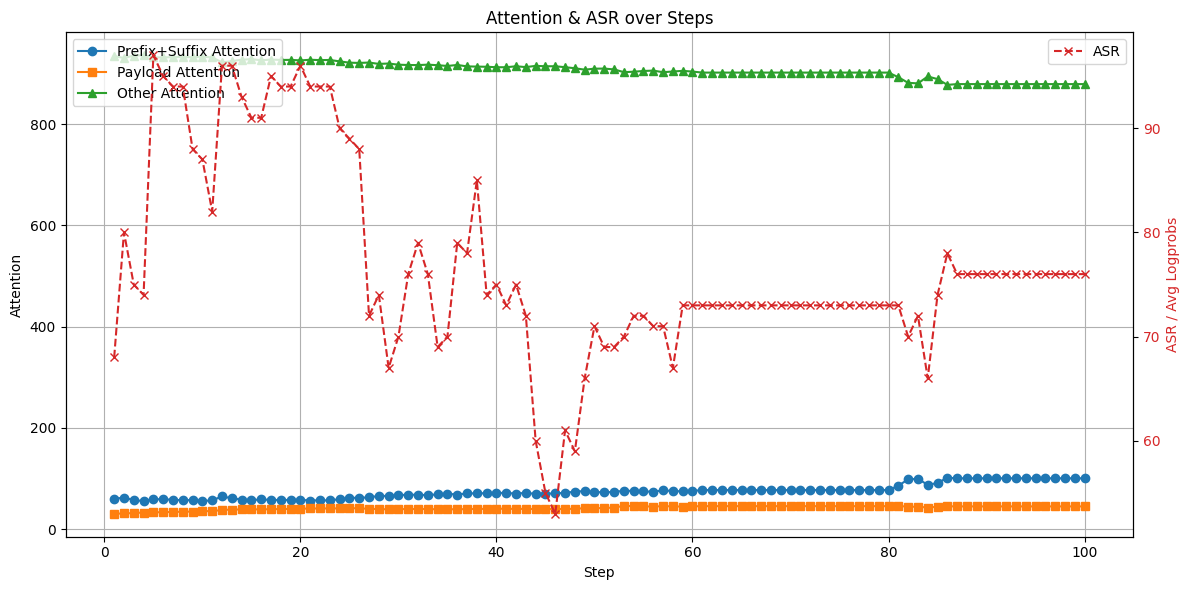

In [6]:
def plot_training_logs(logger, num_rounds, points_per_round, gap=5):

    astra_tokens_seq_result = list(logger.query({"variable_name": "astra_tokens_sequences_list"}))
    prefix_suffix_attn_result = list(logger.query({"variable_name": "prefix_suffix_attention_list"}))
    payload_attn_result = list(logger.query({"variable_name": "payload_attention_list"}))
    background_attn_result = list(logger.query({"variable_name": "other_attention_list"}))
    asr_result = list(logger.query({"variable_name": "astra_logprobs_lists_list"}))

    loss = list(logger.query({"variable_name": "current_best_true_loss_chunk"}))

    print("prefix_suffix_attn_result",prefix_suffix_attn_result)
    print("payload_attn_result",payload_attn_result)
    print("background_attn_result",background_attn_result)

    prefix_suffix_attn_result = prefix_suffix_attn_result[points_per_round]
    payload_attn_result = payload_attn_result[points_per_round]
    background_attn_result = background_attn_result[points_per_round]
    # prefix_suffix_attn_result = prefix_suffix_attn_result[points_per_round + 2]
    # payload_attn_result = payload_attn_result[points_per_round + 2]
    # background_attn_result = background_attn_result[points_per_round + 2]
    asr_result = asr_result[0][0]
    # 打印检查
    # print("astra_tokens_sequences_list:", astra_tokens_seq_result)
    # print("prefix_suffix_attention_list:", prefix_suffix_attn_result)
    # print("payload_attention_list:", payload_attn_result)
    # print("other_attention_list:", background_attn_result)
    # print("astra_logprobs_lists_list:", asr_result)

    steps = list(range(1, points_per_round + 1))  # x 轴步数

    fig, ax1 = plt.subplots(figsize=(12,6))

    # 左 y 轴 - 注意力
    ax1.plot(steps, prefix_suffix_attn_result, label="Prefix+Suffix Attention", marker='o', color='tab:blue')
    ax1.plot(steps, payload_attn_result, label="Payload Attention", marker='s', color='tab:orange')
    ax1.plot(steps, background_attn_result, label="Other Attention", marker='^', color='tab:green')
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Attention", color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True)
    ax1.legend(loc='upper left')

    # 右 y 轴 - ASR
    ax2 = ax1.twinx()
    ax2.plot(steps, asr_result, label="ASR", marker='x', linestyle='--', color='tab:red')
    ax2.set_ylabel("ASR / Avg Logprobs", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')

    plt.title("Attention & ASR over Steps")
    plt.tight_layout()
    plt.show()


# logger_sst_2_0_25 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25/")
# plot_training_logs(logger_sst_2_0_25,1,100)

logger_sst_2_0_20 = experiment_logger.ExperimentLogger("/home/dataset/2024_zox_llm/code/better_opts_attacks/logs/sst-2_0-25/")
plot_training_logs(logger_sst_2_0_20,1,100)